#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

dataset ='Cr-Co-W' # 'Fe-Mo'# 'Fe-Mo'  # 
components = dataset.split('-')
system=dataset.replace('-','')
from BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()
PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

# Prepare Extra features

In [3]:
from importlib.machinery import SourceFileLoader

In [4]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [5]:
Featurizer = SourceFileLoader('Featurizer', '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/Featurizer.py').load_module().Featurizer

In [6]:
Features = Featurizer(BS)

In [7]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [8]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [9]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [10]:
MagneticFeature = Features.MagFeature
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [11]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [12]:
SublatticeSorters

Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/A15-AB.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                        [7, 8, 9, 10, 11, 12, 13, 14]
Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/A15-AB/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                           [7, 8, 9, 10, 11, 12, 13, 14]
Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/A15-BA.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                        [9, 10, 11, 12, 13, 14, 7, 8]
Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/A15-BA/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                           [9, 10, 11, 12, 13, 14, 7, 8]
Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/B2-AB.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                                                [7, 8]
                                                                                                                         ...                        
Cr-Co-W/data/Co_pv/POSCAR-initial/chi/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial               [7, 8, 

In [13]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/1644 [00:00<?, ?it/s]

## Position Features

In [14]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [15]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [16]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [17]:
from mendeleev import element

In [18]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [19]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [20]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [21]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [22]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

In [23]:
BS['atoms_objects'] = PymatgenStructures

# ACE Features 

In [25]:
from ase.atoms import Atoms

In [26]:
def reset_symbols(a: Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [27]:
from importlib.machinery import SourceFileLoader

In [28]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
MyPyAceConfig = SourceFileLoader('ACEer', 'Tools/DatasetTools/ACEDescriptors.py').load_module().default_options_dict
MyPyACECalculator = SourceFileLoader('ACEer', 'Tools/DatasetTools/ACEDescriptors.py').load_module().MyPyACECalculator
default_options = SourceFileLoader('ACEer', 'Tools/DatasetTools/ACEDescriptors.py').load_module().default_options_dict

In [107]:
from pyace import ACEBBasisSet, PyACECalculator

In [29]:
AceConfig = copy.copy(MyPyAceConfig)

In [30]:
AceConfig['elements'] = dataset.split('-')

In [31]:
AceConfig['elements']

['Cr', 'Co', 'W']

In [32]:
ACEer = MyPyACECalculator(components = components, multispace_basis_config = AceConfig)

In [41]:
ACEer.multispace_basis_config

{'deltaSplineBins': 0.001,
 'elements': ['Cr', 'Co', 'W'],
 'embeddings': {'ALL': {'fs_parameters': [10, 1],
   'ndensity': 1,
   'npot': 'FinnisSinclair'}},
 'bonds': {'ALL': {'NameOfCutoffFunction': 'cos',
   'core-repulsion': [10000.0, 10],
   'dcut': 0.01,
   'radbase': 'SBessel',
   'radparameters': [2.0],
   'rcut': 7}},
 'functions': {'ALL': {'nradmax_by_orders': [15, 3, 2, 1, 1],
   'lmax_by_orders': [0, 3, 2, 1, 0]}}}

In [45]:
ACEer.__dict__

{'multispace_basis_config': {'deltaSplineBins': 0.001,
  'elements': ['Cr', 'Co', 'W'],
  'embeddings': {'ALL': {'fs_parameters': [10, 1],
    'ndensity': 1,
    'npot': 'FinnisSinclair'}},
  'bonds': {'ALL': {'NameOfCutoffFunction': 'cos',
    'core-repulsion': [10000.0, 10],
    'dcut': 0.01,
    'radbase': 'SBessel',
    'radparameters': [2.0],
    'rcut': 7}},
  'functions': {'ALL': {'nradmax_by_orders': [15, 3, 2, 1, 1],
    'lmax_by_orders': [0, 3, 2, 1, 0]}}},
 'bbasis_configuration': BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Co', 'Cr', 'W', 'Co Cr', 'Co W', 'Cr Co', 'Cr W', 'W Co', 'W Cr', 'Co Cr W', 'Cr Co W', 'W Co Cr', ]),
 'configured_calculator': <pyace.asecalc.PyACECalculator at 0x145e2f644190>}

In [49]:
bbasis_config = ACEer.bbasis_configuration

In [52]:
bbasis_config.__dir__()

['__init__',
 '__doc__',
 '__module__',
 'funcspecs_blocks',
 'deltaSplineBins',
 'is_sort_functions',
 'auxdata',
 'save',
 'load',
 'validate',
 'get_all_coeffs',
 'set_all_coeffs',
 'get_radial_coeffs',
 'set_radial_coeffs',
 'get_func_coeffs',
 'set_func_coeffs',
 'metadata',
 'copy',
 '__repr__',
 'total_number_of_functions',
 '__getstate__',
 '__setstate__',
 '__add__',
 '__iadd__',
 '__new__',
 '__hash__',
 '__str__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__reduce_ex__',
 '__reduce__',
 '__subclasshook__',
 '__init_subclass__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__']

In [72]:
bbasis_config.funcspecs_blocks[2]

BBasisFunctionsSpecificationBlock(block_name='W', npoti=FinnisSinclair, fs_parameters=[10, 1],  nradmaxi=3, lmaxi=3, nradbaseij=15, radbase=SBessel, radparameters=[2], rcutij=7, dcutij=0.01, NameOfCutoffFunctionij=cos, radcoefficients=[[[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]], funcspecs=[69 funcs ])

In [73]:
from pyace.basisextension import construct_bbasisconfiguration

In [118]:
bbasis = construct_bbasisconfiguration(ACEer.multispace_basis_config)

In [119]:
bbasis

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Co', 'Cr', 'W', 'Co Cr', 'Co W', 'Cr Co', 'Cr W', 'W Co', 'W Cr', 'Co Cr W', 'Cr Co W', 'W Co Cr', ])

In [126]:
new_blocks=[]
for block in  bbasis.funcspecs_blocks:
    thefuncs = block.funcspecs

    chosenfuncs = [ thisfunc for thisfunc in thefuncs if 3 in thisfunc.ls ]

    block.funcspecs=chosenfuncs
    new_blocks.append(block)

In [128]:
bbasis.funcspecs_blocks=new_blocks

In [129]:
new_calculator = PyACECalculator(bbasis)

In [131]:
anatoms.calc=new_calculator

In [132]:
anatoms.get_potential_energy()

0.0

In [133]:
anatoms.calc.projections.shape

(24, 45)

In [106]:
bset=ACEBBasisSet(bbasis)

In [59]:
anatoms = AtomsObjects.atoms[0]

In [61]:
oneprojections = ACEer.get_ace_projections(anatoms)

In [63]:
oneprojections.shape

(24, 808)

In [80]:
oneprojections

array([[ 2.41372814,  2.58725692,  1.46907016, ..., 23.03859626,
        24.2216908 , 25.46554047],
       [ 2.41372814,  2.58725692,  1.46907016, ..., 23.03859626,
        24.2216908 , 25.46554047],
       [ 2.41372814,  2.58725692,  1.46907016, ..., 23.03859626,
        24.2216908 , 25.46554047],
       ...,
       [ 1.87896098,  3.11617959,  2.77319422, ..., 36.92443539,
        29.03396824, 22.82963308],
       [ 1.87896098,  3.11617959,  2.77319422, ..., 36.92443539,
        29.03396824, 22.82963308],
       [ 1.87896097,  3.1161794 ,  2.77319436, ..., 36.92443398,
        29.03396604, 22.8296305 ]])

In [34]:
ACEFEATURES = AtomsObjects['atoms'].map(ACEer.get_ace_projections)
ACEFEATURES.name = 'ace_projections'

# 1 - How can I filter for projections of d only ?

# 2 - How can I extract hierarchical functions?

In [40]:
expand_ace = gf.array_expansions(ACEFEATURES.to_frame(),['ace_projections']) 

In [41]:
CNAV_ACE = gf.featurize_dataframe(expand_ace, CNList)

In [42]:
CNAV_ACE

,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,ace_projections_1_CN15,ace_projections_1_CN16,ace_projections_2_0,ace_projections_2_CN12,ace_projections_2_CN13,ace_projections_2_CN14,...,ace_projections_806_CN13,ace_projections_806_CN14,ace_projections_806_CN15,ace_projections_806_CN16,ace_projections_807_0,ace_projections_807_CN12,ace_projections_807_CN13,ace_projections_807_CN14,ace_projections_807_CN15,ace_projections_807_CN16
Cr_pv10Co_pv14.C36-BABBA.FM,3.323340,2.209222,0.000000,0.000000,0.000000,1.114118,1.858410,1.399806,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
Co_pv14W_sv16.sigma-AABBA.FM,2.769232,0.813832,0.000000,1.657949,0.297451,0.000000,1.499002,0.356213,0.000000,1.064848,...,0.0,0.000000,0.000000,0.000000,465.998289,117.011961,0.0,288.211026,60.775301,0.000000
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,3.401895,2.259858,0.000000,0.000000,0.000000,1.142037,1.918084,1.417920,0.000000,0.000000,...,0.0,0.000000,0.000000,3.092988,14.291953,8.496061,0.0,0.000000,0.000000,5.795892
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,2.396414,1.680457,0.000000,0.000000,0.000000,0.715958,1.298969,1.113745,0.000000,0.000000,...,0.0,0.000000,0.000000,3.215870,13.014184,10.169727,0.0,0.000000,0.000000,2.844457
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,2.394997,1.689537,0.000000,0.000000,0.000000,0.705459,1.300367,1.139284,0.000000,0.000000,...,0.0,0.000000,0.000000,3.139925,13.163905,10.442781,0.0,0.000000,0.000000,2.721125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,3.142677,1.332672,1.356755,0.000000,0.000000,0.453249,1.726176,0.847964,0.712523,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
Cr_pv2W_sv11.mu-BBABB.FM,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,113.500796,107.506449,94.221334,4556.630091,2541.673095,0.0,405.383468,467.213797,1142.359731
Cr_pv20Co_pv4.C36-BAAAA.FM,0.929372,0.573207,0.000000,0.000000,0.000000,0.356165,0.400044,0.127841,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,2.421659,1.559371,0.000000,0.000000,0.000000,0.862288,1.477222,0.906665,0.000000,0.000000,...,0.0,0.000000,0.000000,21.434538,139.329610,69.842579,0.0,0.000000,0.000000,69.487031


In [43]:
selection = CNAV_ACE[Features.StrucNames == 'bcc'].filter(regex='_0$')

In [44]:
selection

,ace_projections_1_0,ace_projections_2_0,ace_projections_3_0,ace_projections_4_0,ace_projections_5_0,ace_projections_6_0,ace_projections_7_0,ace_projections_8_0,ace_projections_9_0,ace_projections_10_0,...,ace_projections_798_0,ace_projections_799_0,ace_projections_800_0,ace_projections_801_0,ace_projections_802_0,ace_projections_803_0,ace_projections_804_0,ace_projections_805_0,ace_projections_806_0,ace_projections_807_0
Co_pv1.bcc.NM,5.941314,3.24047,4.562015,1.116414,-0.963921,5.709721,7.400956,3.847538,5.114981,3.204493,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
Cr_pv1.bcc.NM,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,5942.724124,0.0,0.0,0.0,0.0,0.000000
W_sv1.bcc.FM,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,10633.119335
W_sv1.bcc.NM,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,10633.119335


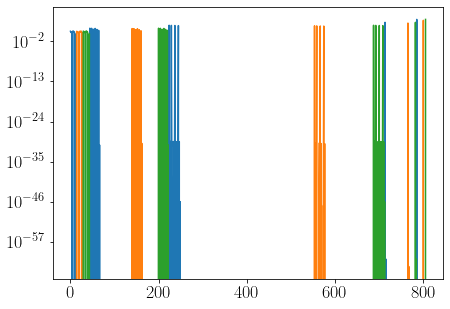

In [46]:
fig, ax = plt.subplots()
ax.plot(selection.iloc[0].values)
ax.plot(selection.iloc[1].values)
ax.plot(selection.iloc[2].values)
ax.set_yscale('log')

In [47]:
ACE_file = os.path.join(descriptorslocation, f'{dataset}-ACE-CNAV.pkl')

In [48]:
CNAV_ACE.to_pickle(ACE_file)

## Canonical 

In [49]:
CanonicalAceConfig = copy.copy(MyPyAceConfig)

In [50]:
CanonicalAceConfig['elements'] = ['W']

In [51]:
CanonicalACEer = MyPyACECalculator(components = CanonicalAceConfig['elements'], multispace_basis_config=CanonicalAceConfig)

In [52]:
canonicalatomsobjects = AtomsObjects['atoms'].map(reset_symbols)

In [53]:
canonicalacedescriptors = canonicalatomsobjects.map(CanonicalACEer.get_ace_projections)
canonicalacedescriptors.name = 'canonical_ace_projections'

In [54]:
expand_canonical_ace = gf.array_expansions(canonicalacedescriptors.to_frame(),['canonical_ace_projections']) 

In [55]:
CNAV_CANONICAL_ACE = gf.featurize_dataframe(expand_canonical_ace, CNList)

In [56]:
CNAV_CANONICAL_ACE

,canonical_ace_projections_1_0,canonical_ace_projections_1_CN12,canonical_ace_projections_1_CN13,canonical_ace_projections_1_CN14,canonical_ace_projections_1_CN15,canonical_ace_projections_1_CN16,canonical_ace_projections_2_0,canonical_ace_projections_2_CN12,canonical_ace_projections_2_CN13,canonical_ace_projections_2_CN14,...,canonical_ace_projections_67_CN13,canonical_ace_projections_67_CN14,canonical_ace_projections_67_CN15,canonical_ace_projections_67_CN16,canonical_ace_projections_68_0,canonical_ace_projections_68_CN12,canonical_ace_projections_68_CN13,canonical_ace_projections_68_CN14,canonical_ace_projections_68_CN15,canonical_ace_projections_68_CN16
Cr_pv10Co_pv14.C36-BABBA.FM,5.695642,3.774540,0.000000,0.000000,0.000000,1.921102,3.137085,2.288817,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.405459e-08,8272.790236,5496.313181,0.00000,0.000000,0.000000,2776.477055
Co_pv14W_sv16.sigma-AABBA.FM,5.943411,1.970484,0.000000,3.176701,0.796227,0.000000,3.270114,1.154853,0.000000,1.726796,...,0.000000e+00,1.598131e-08,7.293952e-11,0.000000e+00,10638.403459,3541.271772,0.00000,5670.327369,1426.804319,0.000000
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,5.837744,3.872651,0.000000,0.000000,0.000000,1.965094,3.247482,2.361995,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.495343e-08,9602.393207,6382.890873,0.00000,0.000000,0.000000,3219.502333
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,5.742081,3.826105,0.000000,0.000000,0.000000,1.915977,3.173047,2.171643,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.483282e-08,8690.339372,5786.866651,0.00000,0.000000,0.000000,2903.472721
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,5.742081,3.821247,0.000000,0.000000,0.000000,1.920835,3.173047,2.166646,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.381191e-10,8690.339372,5789.464179,0.00000,0.000000,0.000000,2900.875193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,5.697194,2.358039,2.357592,0.000000,0.000000,0.981563,3.090750,1.331103,1.267668,0.000000,...,4.819967e-09,0.000000e+00,0.000000e+00,9.302016e-11,8143.217457,3365.630170,3378.45559,0.000000,0.000000,1399.131697
Cr_pv2W_sv11.mu-BBABB.FM,5.836784,3.092910,0.000000,0.914647,0.930447,0.898780,3.255495,1.908535,0.000000,0.478314,...,0.000000e+00,1.177080e-03,2.793603e-14,5.116303e-07,9765.090687,5358.542952,0.00000,1392.798737,1315.890787,1697.858211
Cr_pv20Co_pv4.C36-BAAAA.FM,5.476135,3.622925,0.000000,0.000000,0.000000,1.853210,2.968291,2.176861,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.319733e-08,6507.843057,4320.581843,0.00000,0.000000,0.000000,2187.261214
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,5.837744,3.890275,0.000000,0.000000,0.000000,1.947470,3.247482,2.220009,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.552359e-08,9602.393207,6394.626108,0.00000,0.000000,0.000000,3207.767099


In [57]:
canonical_ACE_file = os.path.join(descriptorslocation, f'{dataset}-canonical-ACE-CNAV.pkl')

In [58]:
CNAV_CANONICAL_ACE.to_pickle(canonical_ACE_file)

In [36]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator
TestMyPyAce = SourceFileLoader('TestMyPyAce', 'Tools/DatasetTools/ACEDescriptors.py').load_module().TestMyPyAce
Test = TestMyPyAce()
Test.setUpClass()

# I think all the following happened in a conversation with Yuri:

``` python

In [38]:
new_multispace_config = copy.deepcopy(Test.default_multispace_config)
new_multispace_config['embeddings'] = {                                                                                  
     'Cr': {
         'npot': 'FinnisSinclairShiftedScaled',
         'fs_parameters': [1, 1], ## non-linear embedding function: 1*rho_1^1 + 1*rho_2^0.5
         'ndensity': 1,
         'rho_core_cut': 2000,
         'drho_core_cut': 250
         }, 

     'Co': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }, 
    'W': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }
     }
new_multispace_config['functions'] = {
                     'UNARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             },
#                      'Mo':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              },
                     'BINARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             }
    }

# new_multispace_config['functions'] = {
#                      'ALL':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              }
#     }

In [ ]:
bas= construct_bbasisconfiguration(new_multispace_config)

bas.funcspecs_blocks[2].funcspecs

bas.funcspecs_blocks[2].funcspecs

construct_bbasisconfiguration??

Test.default_multispace_config

construct_bbasisconfiguration(Test.default_multispace_config)



ShorterFunctionsOptions = copy.deepcopy(default_options)

ShorterFunctionsOptions['functions'] = new_functions

ShorterFunctionsACE = MyPyACECalculator(components=['Fe','Mo'], multispace_basis_config=ShorterFunctionsOptions)

ACEFEATURES_shorter_functions = AtomsObjects['atoms'].map(ShorterFunctionsACE.get_ace_projections)
ACEFEATURES.name = 'ace_projections_shorter_functions'
```

# SOAPFeatures

In [61]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [62]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [63]:
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

In [64]:
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])

## Canonical

In [65]:
def reset_symbols(a: ase.atoms.Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [66]:
soapcases = ['canonicalW', 'specific']

In [67]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [68]:
for soapcase in soapcases:
    print(soapcase)
    soap_features_file.update({soapcase: os.path.join(descriptorslocation, f'soap_features__{soapcase}__{params_str}.kpl')})
    if 'canonicalFe' in soapcase:
        species=[26]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'Fe'))
    elif 'canonicalW' in soapcase:
        species=[74]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'W'))
    elif 'specific' in soapcase:
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: copy.deepcopy(a))
    SOAPER = SOAP(species=species, **soap_params)
    SOAPFEATURES.update({soapcase: thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
    EXPANDED_SOAP.update({soapcase: gf.array_expansions(SOAPFEATURES[soapcase].to_frame(name='SOAP'), ['SOAP'])})
    AVE_SOAP.update({soapcase: gf.featurize_dataframe(EXPANDED_SOAP[soapcase], CNList)})
    variances.update({soapcase: {name: col.var() for name, col in AVE_SOAP[soapcase].iteritems()}})
    selector = VarianceThreshold(threshold=1e-7)
    SEL_SOAP.update({soapcase: selector.fit_transform(AVE_SOAP[soapcase])})
    FINAL_SOAP.update({soapcase: pd.DataFrame(data=SEL_SOAP[soapcase], columns = selector.get_feature_names_out(), index=AVE_SOAP[soapcase].index)})
    FINAL_SOAP[soapcase].to_pickle(soap_features_file[soapcase])

canonicalW
specific


In [69]:
soap_features_file

{'canonicalW': 'Cr-Co-W/Descriptors/soap_features__canonicalW__rcut_4__nmax_9__lmax_6__sigma_0.1__rbf_gto__periodic_True__crossover_True.kpl',
 'specific': 'Cr-Co-W/Descriptors/soap_features__specific__rcut_4__nmax_9__lmax_6__sigma_0.1__rbf_gto__periodic_True__crossover_True.kpl'}

# Pyscal features 

In [70]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [71]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

##  Coordination Numbers

In [72]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [73]:
PyscalFeatures

,pyscal_steinhardt_0,pyscal_steinhardt_1,pyscal_cn
Cr_pv10Co_pv14.C36-BABBA.FM,"[0.0053385417813247935, 0.005338541781324821, ...","[0.1942883561066591, 0.19428835610665907, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 16, 1..."
Co_pv14W_sv16.sigma-AABBA.FM,"[0.09617556302880145, 0.09617556302880122, 0.0...","[0.645723632201294, 0.6457236322012941, 0.3158...","[12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1..."
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,"[0.011022436115045518, 0.011022436115045569, 0...","[0.19197958595047768, 0.19197958595047768, 0.1...","[16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1..."
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,"[0.0053385417813247935, 0.005338541781324706, ...","[0.1942883561066591, 0.19428835610665904, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 16, 16, 16, 1..."
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,"[0.011022436115045572, 0.011022436115045456, 0...","[0.1919795859504777, 0.1919795859504777, 0.191...","[16, 16, 16, 16, 12, 12, 12, 12, 16, 16, 16, 1..."
...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,"[0.03160847926125844, 0.07272265497611828, 0.0...","[0.19382539926827577, 0.451909678646869, 0.451...","[16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1..."
Cr_pv2W_sv11.mu-BBABB.FM,"[0.0016125060908427345, 0.0016125060908423706,...","[0.29326918583364187, 0.29326918583364175, 0.6...","[15, 15, 12, 12, 12, 12, 12, 12, 12, 16, 16, 1..."
Cr_pv20Co_pv4.C36-BAAAA.FM,"[0.00533854178132472, 0.005338541781324761, 0....","[0.1942883561066591, 0.19428835610665912, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 1..."
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,"[0.005338541781324651, 0.0053385417813247545, ...","[0.1942883561066591, 0.19428835610665904, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 1..."


## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [74]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [75]:
intersect = thisFeatures.index.intersection(CNList.index)

In [76]:
CNPyscal  = gf.featurize_many(thisFeatures.loc[intersect], CNList[intersect], [gf.cn_average])

  0%|          | 0/1 [00:00<?, ?it/s]

In [78]:
CNPyscal

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN13,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN13,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Cr_pv10Co_pv14.C36-BABBA.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Co_pv14W_sv16.sigma-AABBA.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,0.028944,0.021523,0.000000,0.000000,0.000000,0.007421,0.502143,0.360095,0.000000,0.000000,0.000000,0.142048
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,0.028944,0.020576,0.000000,0.000000,0.000000,0.008368,0.502143,0.360479,0.000000,0.000000,0.000000,0.141663
...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,0.081875,0.046632,0.030092,0.000000,0.000000,0.005151,0.471315,0.250462,0.186997,0.000000,0.000000,0.033856
Cr_pv2W_sv11.mu-BBABB.FM,0.043541,0.036474,0.000000,0.004550,0.000248,0.002268,0.478648,0.340808,0.000000,0.061350,0.045118,0.031371
Cr_pv20Co_pv4.C36-BAAAA.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,0.028944,0.021523,0.000000,0.000000,0.000000,0.007421,0.502143,0.360095,0.000000,0.000000,0.000000,0.142048


In [79]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [80]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Features 

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

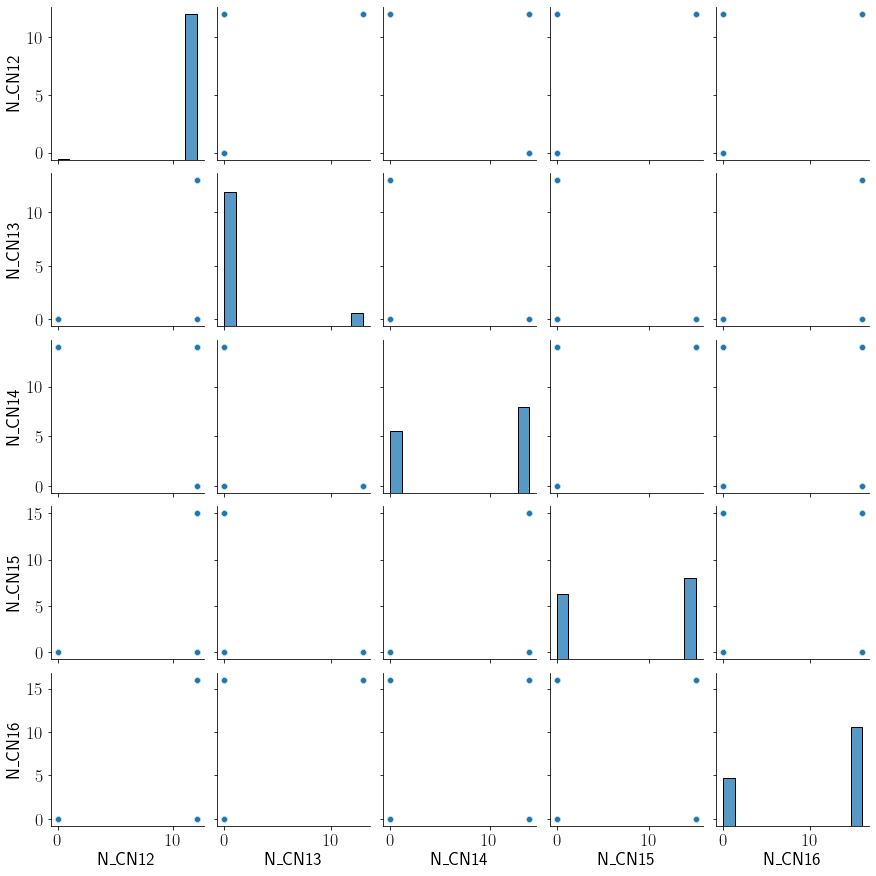

In [82]:
sns.pairplot(CN)

##  Correlations

In [83]:
plt.rc('font',size=22)

In [84]:
BS['EF'] = BS['EF'].astype(float)

In [85]:
FeatureGroups = {'density features': DensitiFeatures, 'atomic features': AtomicFeaturesMagpie, 'composition features': CompositionFeatures, 'Dataset Features': DatasetFeatures}
TargetCorrelations = {groupname: GroupFeatures.corrwith(BS['EF']).abs().dropna().sort_values(ascending=False) for groupname, GroupFeatures in FeatureGroups.items()}

In [86]:
len(TargetCorrelations)

4

[None]

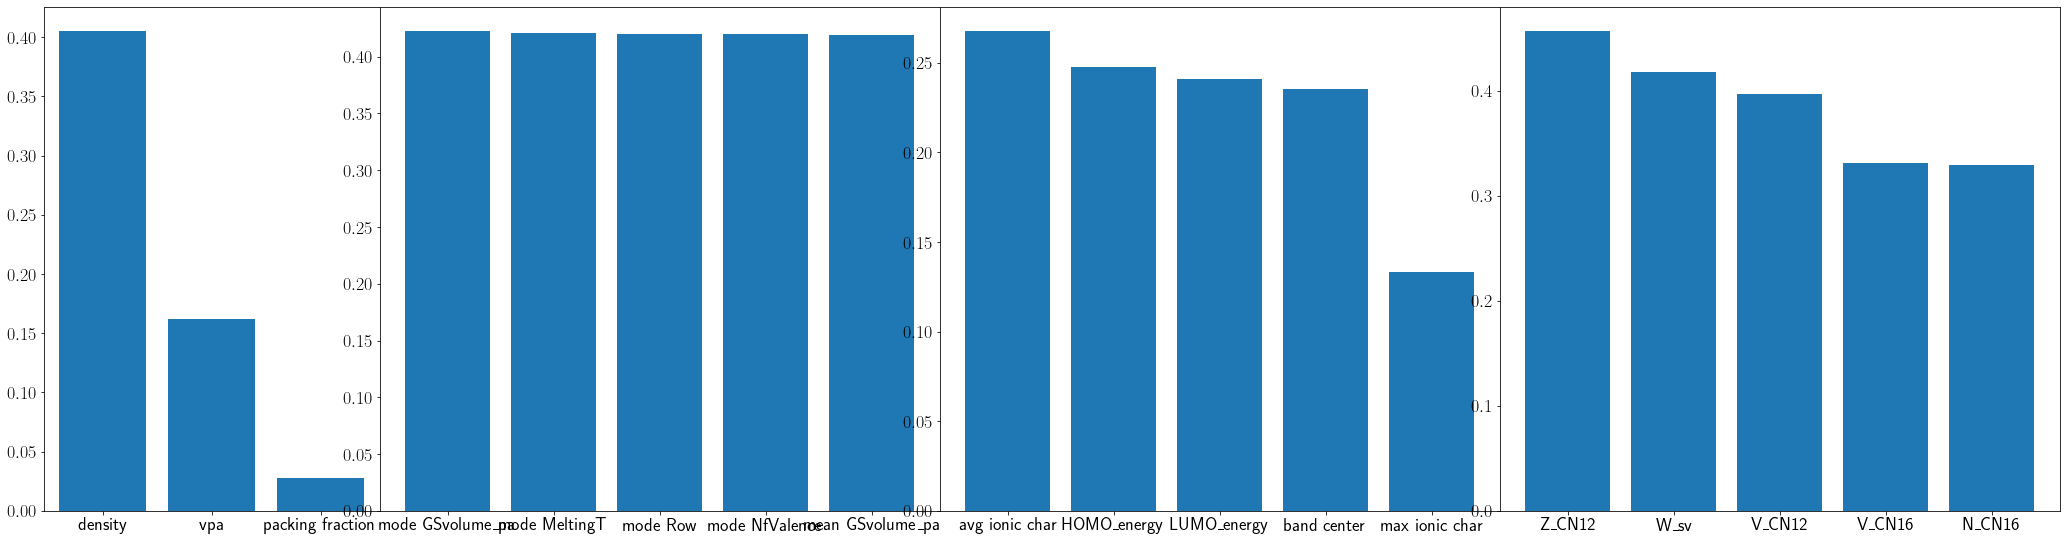

In [87]:
fig = plt.figure(figsize=(len(TargetCorrelations)*7, 10))
border=0
totalfeatures=18
for i, (group, TargetCorr) in enumerate(TargetCorrelations.items()):
    nfeatures = len(TargetCorr[:5])
    ax = fig.add_axes([border/totalfeatures,0.2,(nfeatures)/totalfeatures,0.7])
    border +=nfeatures
    ax.bar( TargetCorr[:5].index,TargetCorr[:5].values) #, ax = ax, orient='vertical')
axes = fig.get_axes()
# [tax.set_yticklabels(tax.get_yticklabels(), visible=False) for tax in axes[1:]]
[tax.sharey(axes[0]) for tax in axes[:1]]
#axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90) 

# Plot correlations for most correlated

In [88]:
for name, item in DensitiFeatures.iteritems():
    print(name)

density
vpa
packing fraction


In [89]:
DensitiFeatures[DensitiFeatures.vpa < 6]

,density,vpa,packing fraction
index,,,
W_sv1.fcc.FM,0.649612,2.576499,0.025403


<AxesSubplot:xlabel='vpa', ylabel='Count'>

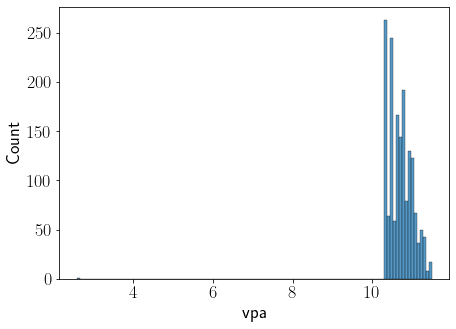

In [90]:
sns.histplot(DensitiFeatures.vpa)

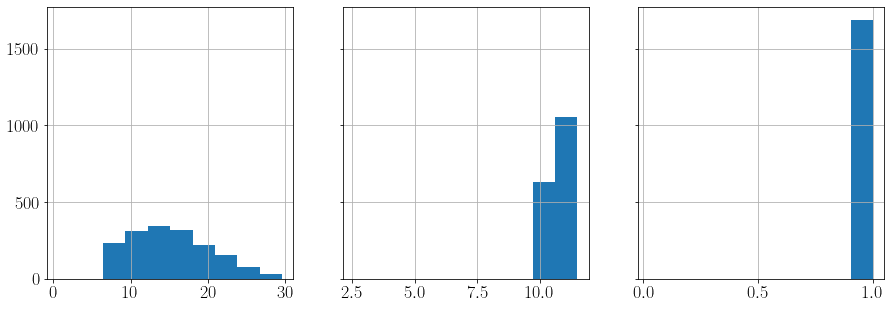

In [91]:
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(15,5))
for (fname, feature), ax in zip(DensitiFeatures.iteritems(), axes):
    feature.hist(ax=ax)
#    sns.histplot(feature, ax =ax)

## By hand outlier detection:

In [92]:
selection = (FeatureGroups['density features']['packing fraction'] < 3) & (FeatureGroups['density features']['vpa']>8) &(FeatureGroups['density features']['density']<75)

In [93]:
def target_correlation_scatters(thisgroup, selection=None):
    featurenames = TargetCorrelations[thisgroup].index.to_list()
    if selection is None:
        selection = FeatureGroups[thisgroup].index
    nplots =  min([4, len(featurenames)])
    fig, axes = plt.subplots(1, nplots,  figsize=(7*4, 10), sharey=True)
    intersect = selection.intersection(BS['EF'].index)
    for ax, thisfeature in zip(axes, featurenames[:nplots]):
        ax.scatter(FeatureGroups[thisgroup][thisfeature][intersect], BS['EF'][intersect])
        ax.set_xlabel(thisfeature)
    axes[0].set_ylabel(r'$\Delta E_f$')

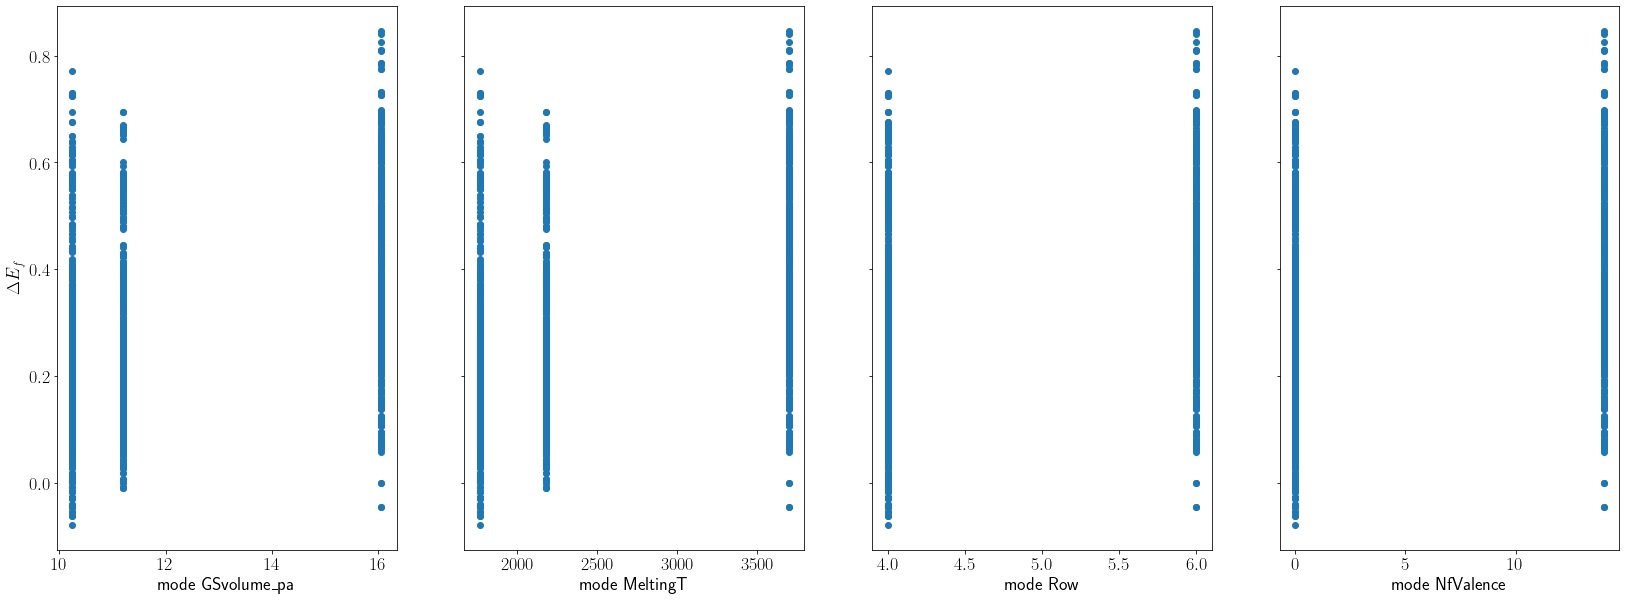

In [94]:
target_correlation_scatters('atomic features')

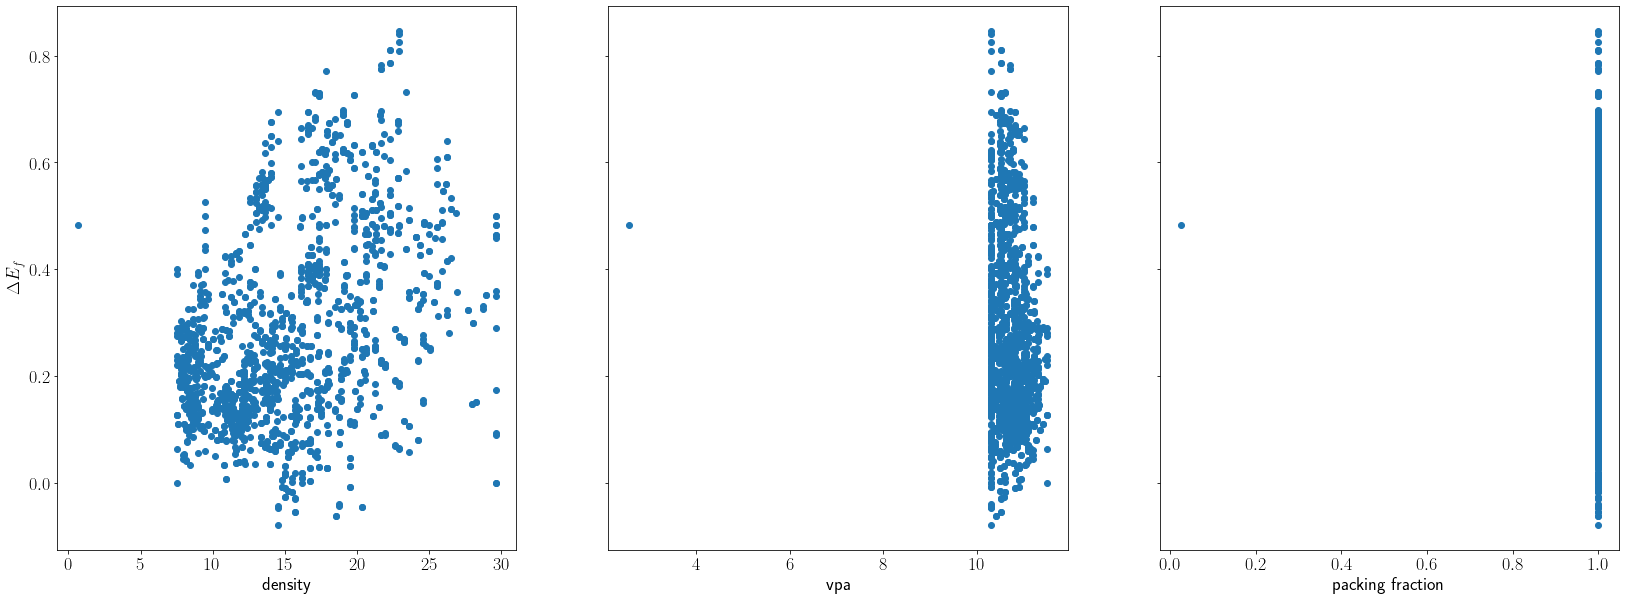

In [95]:
target_correlation_scatters('density features')#, selection=selection)

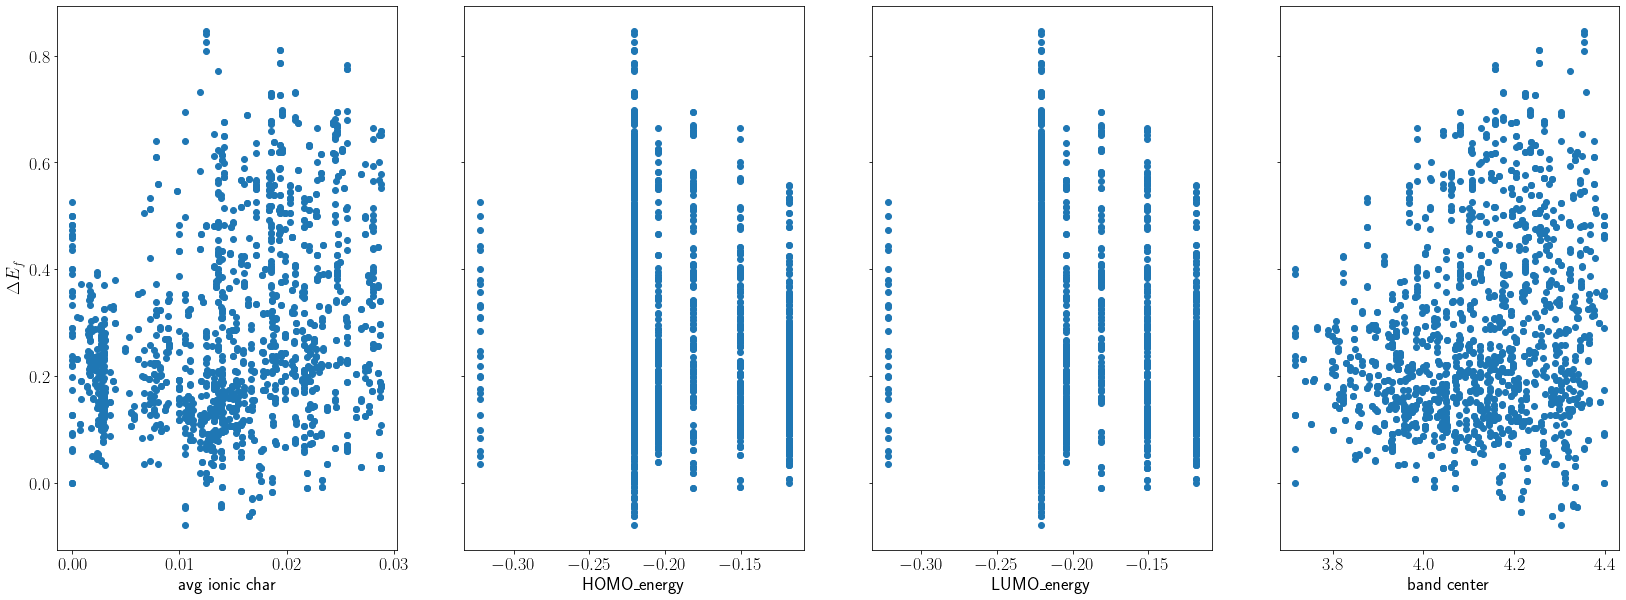

In [96]:
target_correlation_scatters('composition features')

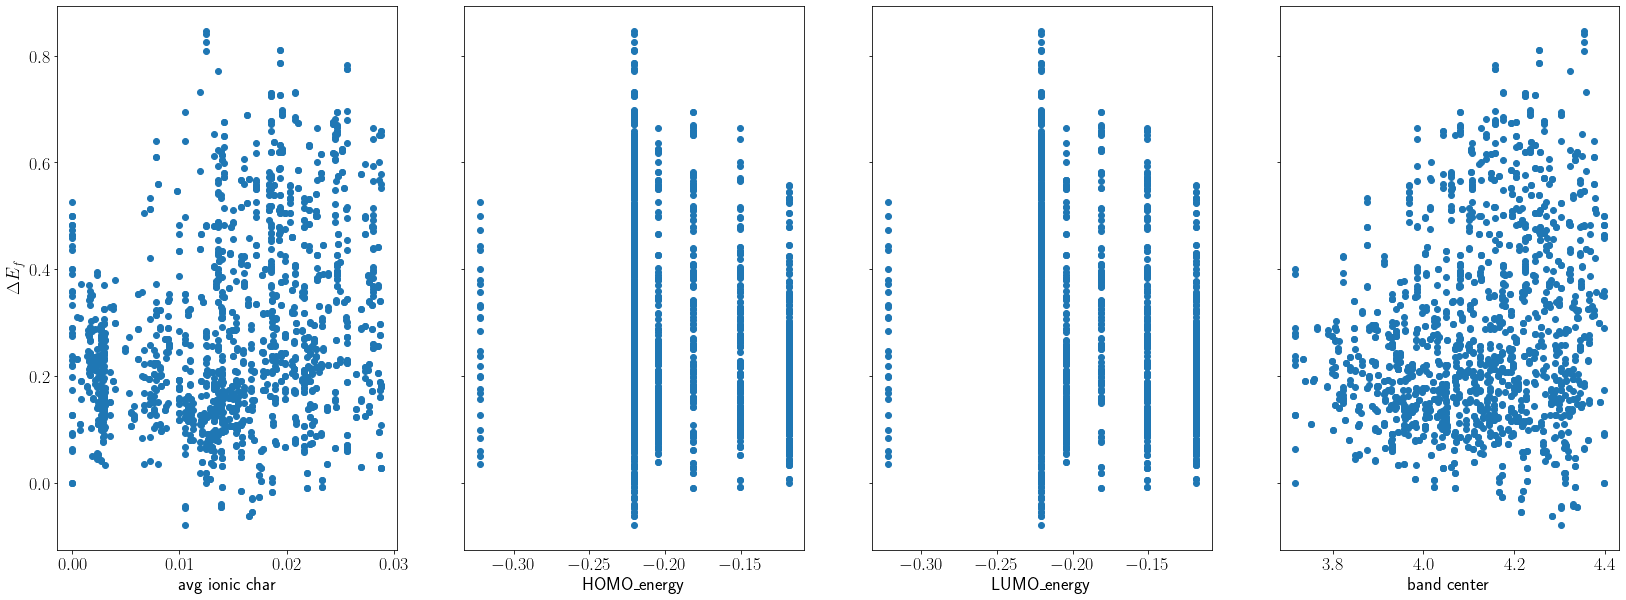

In [97]:
target_correlation_scatters('composition features')

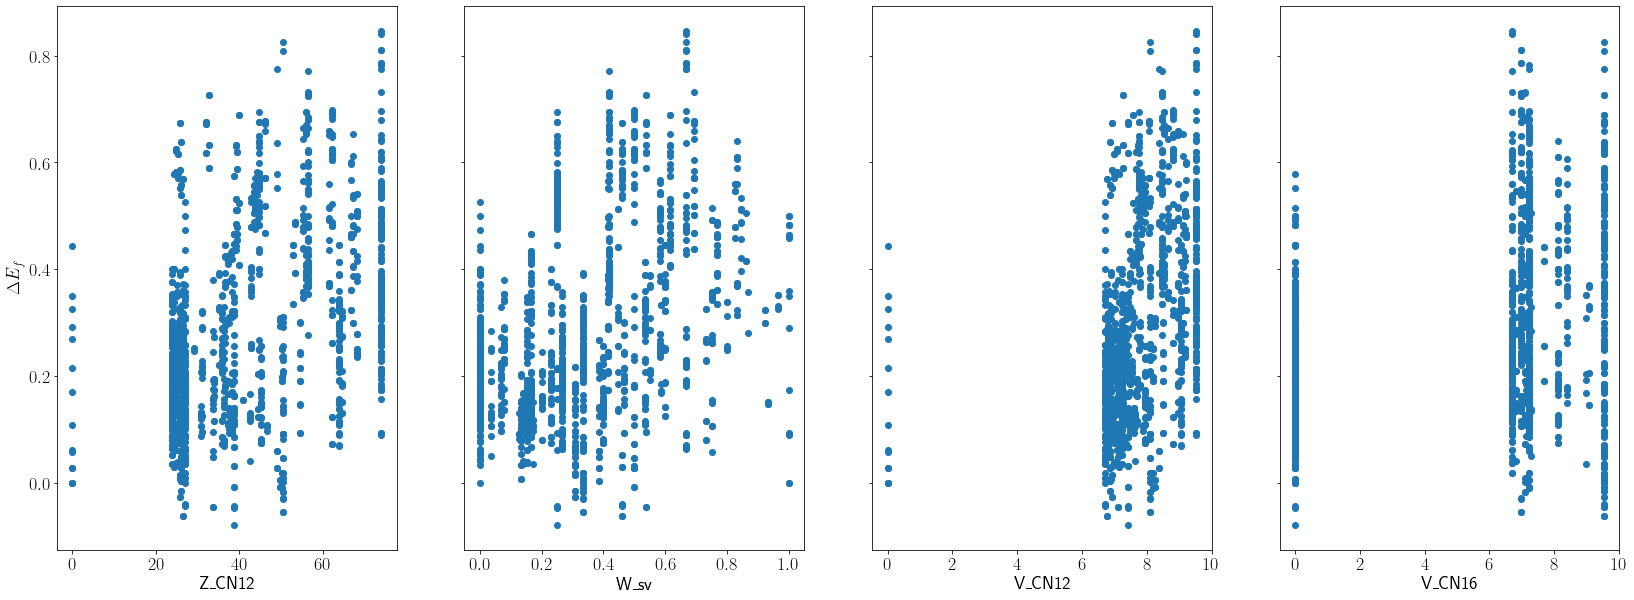

In [98]:
target_correlation_scatters('Dataset Features')

In [99]:
TargetCorrelations.keys()

dict_keys(['density features', 'atomic features', 'composition features', 'Dataset Features'])